# Точечные проверки и статистическое тестирование

Четвёртый заключительный шаг проекта: проверяем гипотезы, сформулированные по итогам EDA (**[3.EDA](3.EDA.ipynb)**), и подтверждаем центральную гипотезу исследования формальным статистическим тестом.

**Что делаем:** разбираем содержательные причины двух локальных находок (скачок `hypothec` в январе-феврале 2026, устойчивое снижение `restructing` за год) через сравнение частотного анализа текста в разные периоды; затем формально проверяем главную гипотезу - о влиянии платных акций за отзывы на распределение оценок - через chi-square тест и Cramer's V.

**Результат ноутбука:** подтверждённые или опровергнутые гипотезы из **[3.EDA](3.EDA.ipynb)**, включая статистически обоснованный вывод о том, что наличие акции за отзывы - основной фактор, объясняющий различия в оценках между банками. Это финальный содержательный результат исследования, на основе которого строится README.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
reviews = pd.read_csv("reviews_clean.csv")
reviews_by_bank = pd.read_csv("reviews_by_bank.csv")

In [3]:
reviews['resolutionIsApproved'] = reviews['resolutionIsApproved'].astype('boolean')
reviews_by_bank['resolutionIsApproved'] = reviews_by_bank['resolutionIsApproved'].astype('boolean')

In [4]:
reviews['dateCreate'] = pd.to_datetime(reviews['dateCreate'])
reviews_by_bank['dateCreate'] = pd.to_datetime(reviews_by_bank['dateCreate'])

In [5]:
reviews['bank'] = reviews['bank'].astype('category')
reviews['product'] = reviews['product'].astype('category')

In [6]:
import ast

reviews_by_bank['bank'] = reviews_by_bank['bank'].astype('category')
reviews_by_bank['product'] = reviews_by_bank['product'].apply(ast.literal_eval)

In [8]:
reviews_filtered = reviews[~reviews['product'].isin(['individual', 'currency_exchange'])]
reviews_full_months = reviews_filtered[reviews_filtered['dateCreate'] < '2026-08-01']

## 1. Точечная проверка находок

### 1.a `hypothec`: скачок в январе-феврале 2026
В ноутбуке **[3.EDA](3.EDA.ipynb)** было найдено: у `hypothec` в январе-феврале 2026 средний grade резко вырос (с ~1.9 до ~2.3) при одновременном провале объёма отзывов (с ~350 до ~140). Проверим, стоит ли за этим содержательный сдвиг в текстах - например, снижение доли жалоб на навязанное страхование жизни (найденное ранее как основная тема жалоб по ипотеке) - или это тот же тип жалоб, просто их временно стало меньше.

**План проверки**: сравнить частотный анализ текстов за январь-февраль 2026 с текстами за остальной период - если темы совпадают, значит, изменился только объём; если темы разные - это более значимая находка.

In [20]:
from sklearn.feature_extraction.text import CountVectorizer

russian_stopwords = ['и', 'в', 'не', 'на', 'что', 'с', 'по', 'это', 'как', 'из',
                      'за', 'то', 'все', 'его', 'но', 'от', 'мне', 'к', 'у', 'я',
                      'бы', 'для', 'мой', 'банк', 'банка', 'банке', 'так', 'при', 
                      'меня', 'было', 'уже', 'после', 'нет', 'через', 'только',
                      'был', 'они', 'чтобы', 'без', 'раз']  # можно дополнить

hypothec_jan_feb = reviews_full_months[
    (reviews_full_months['product'] == 'hypothec') &
    (reviews_full_months['dateCreate'].dt.strftime('%Y-%m').isin(['2026-01', '2026-02']))
]

hypothec_rest = reviews_full_months[
    (reviews_full_months['product'] == 'hypothec') &
    (~reviews_full_months['dateCreate'].dt.strftime('%Y-%m').isin(['2026-01', '2026-02']))
]

print(f"Январь-февраль: {len(hypothec_jan_feb)} отзывов, средний grade: {hypothec_jan_feb['grade'].mean():.2f}")
print(f"Остальной период: {len(hypothec_rest)} отзывов, средний grade: {hypothec_rest['grade'].mean():.2f}")

def top_words(texts, stopwords_list, n=20):
    vectorizer = CountVectorizer(stop_words=stopwords_list, max_features=n, token_pattern=r'[а-яё]{3,}')
    word_counts = vectorizer.fit_transform(texts)
    words = vectorizer.get_feature_names_out()
    counts = word_counts.sum(axis=0).A1.tolist()
    return sorted(zip(words, counts), key=lambda x: -x[1])

print("\n=== hypothec, январь-февраль 2026 (все оценки) ===")
print(top_words(hypothec_jan_feb['text'], russian_stopwords))

print("\n=== hypothec, остальной год (все оценки) ===")
print(top_words(hypothec_rest['text'], russian_stopwords))

Январь-февраль: 263 отзывов, средний grade: 2.37
Остальной период: 2319 отзывов, средний grade: 1.95

=== hypothec, январь-февраль 2026 (все оценки) ===
[('документы', 151), ('ипотеку', 136), ('домклик', 133), ('день', 118), ('была', 116), ('ипотеке', 107), ('года', 105), ('ипотеки', 102), ('вопрос', 97), ('чат', 91), ('деньги', 90), ('менеджер', 84), ('ответ', 82), ('сотрудник', 80), ('очень', 79), ('чате', 79), ('есть', 78), ('платеж', 78), ('этом', 76), ('время', 75)]

=== hypothec, остальной год (все оценки) ===
[('домклик', 2846), ('сбербанк', 2047), ('плюс', 1895), ('договора', 1413), ('жизни', 1348), ('ставки', 1262), ('ипотеки', 1095), ('документы', 1092), ('договор', 1088), ('года', 1086), ('ипотеку', 1069), ('была', 1054), ('услуг', 1053), ('ипотеке', 1051), ('страхование', 1039), ('ставка', 1009), ('пао', 983), ('день', 892), ('условия', 860), ('ставку', 840)]


In [21]:
def plot_top_words(word_counts, title, n=15, ax=None):
    words, counts = zip(*word_counts[:n])
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(words[::-1], counts[::-1])
    ax.set_title(title)
    ax.set_xlabel('Частота')
    return ax

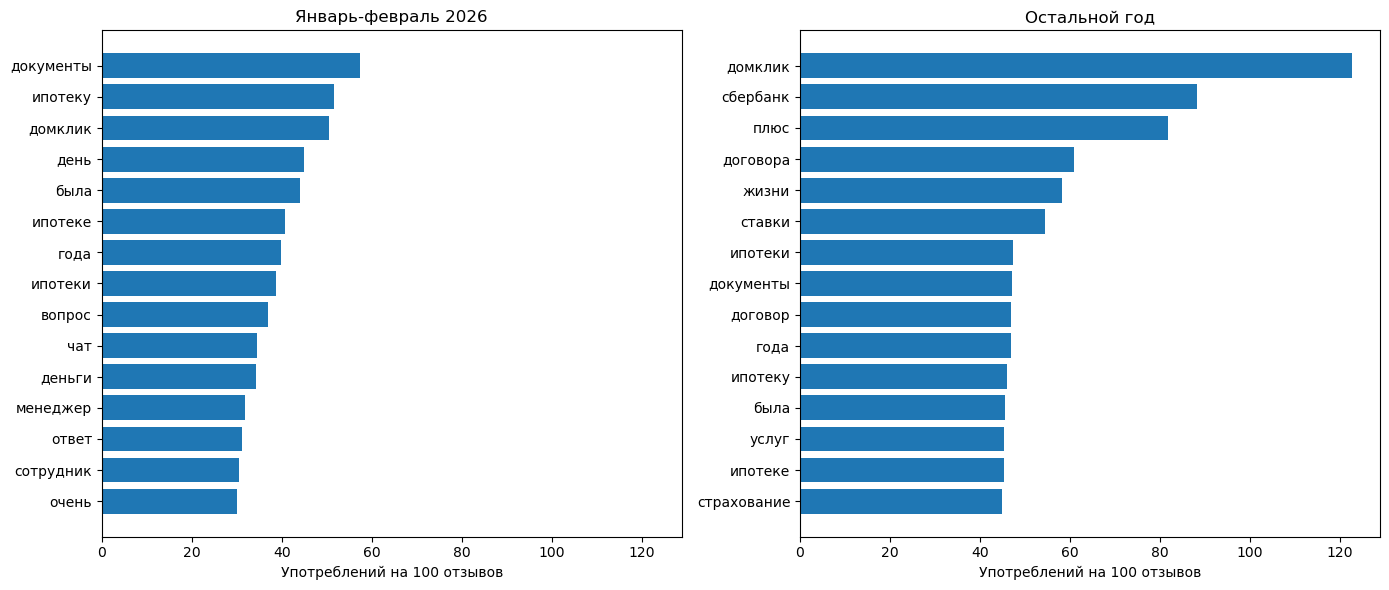

In [22]:
def top_words_normalized(texts, stopwords_list, n=15):
    vectorizer = CountVectorizer(stop_words=stopwords_list, max_features=n, token_pattern=r'[а-яё]{3,}')
    word_counts = vectorizer.fit_transform(texts)
    words = vectorizer.get_feature_names_out()
    counts = word_counts.sum(axis=0).A1
    # нормализация: частота на 100 отзывов
    normalized_counts = counts / len(texts) * 100
    return sorted(zip(words, normalized_counts), key=lambda x: -x[1])

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)
plot_top_words(top_words_normalized(hypothec_jan_feb['text'], russian_stopwords), 
               'Январь-февраль 2026', ax=axes[0])
plot_top_words(top_words_normalized(hypothec_rest['text'], russian_stopwords), 
               'Остальной год', ax=axes[1])
axes[0].set_xlabel('Употреблений на 100 отзывов')
axes[1].set_xlabel('Употреблений на 100 отзывов')
plt.tight_layout()
plt.show()

#### Вывод

Увиденное подтверждает и уточняет находку - есть реальный содержательный сдвиг, не только цифровой.

В обычный период тема страхования доминирует: `страхование`, `жизни`, `ставки`, `ставка`, `договора`, `услуг` прочно в топ-20 - это подтверждает находку про навязанное страхование жизни как основную тему жалоб по ипотеке.

В январе-феврале эта тема почти исчезает из топа - вместо неё поднимаются `менеджер`, `сотрудник`, `чат`, `ответ`, `вопрос`, `платеж`, `время`. То есть в этот период отзывы больше про процесс общения с банком. Это логично объясняет и рост среднего grade: жалобы на страхование, судя по всему, самые "тяжёлые" и снижают оценку сильнее всего, а меньше таких жалоб в этот период → выше средняя оценка.  

Также заметно, что Сбербанк выпал из топ-20 в январе-феврале (был на 2 месте весь год) — это не проверялось дополнительно, отмечаю как наблюдение.

In [11]:
def share_with_word(df, word):
    return df['text'].str.contains(word, case=False, na=False).mean()

print(f"Январь-февраль: доля с 'страхован': {share_with_word(hypothec_jan_feb, 'страхован'):.2%}")
print(f"Остальной год: доля с 'страхован': {share_with_word(hypothec_rest, 'страхован'):.2%}")

Январь-февраль: доля с 'страхован': 14.45%
Остальной год: доля с 'страхован': 30.19%


Хорошее числовое подтверждение: доля отзывов со словом "страхован" падает более чем вдвое - с 30.2% в обычный период до 14.5% в январе-феврале. Это надёжно подтверждает находку: сдвиг в теме реален, не показался только из-за выборки топ-20 слов.

### 1.b `restructing`: устойчивое снижение за год
`restructing` (реструктуризация/рефинансирование) показал устойчивое снижение среднего grade за год - с индекса 100 в начале до ~83 к концу, причём именно планомерное снижение, без скачков (в отличие от ипотеки, где был резкий эпизод). При этом объём отзывов не падал - то есть дело не в том, что стало меньше отзывов, люди продолжали писать так же часто, но со временем всё менее позитивно.  

Проверим: является ли это реальным сдвигом в содержании жалоб, или это общий фоновый эффект (например, совпадает по времени с уже найденным ранее летним спадом у нескольких банков) - тем же способом, что и с ипотекой: сравним топ-слова в начале периода и в конце.

Ранний период: 528 отзывов, средний grade: 4.15
Поздний период: 464 отзывов, средний grade: 3.62


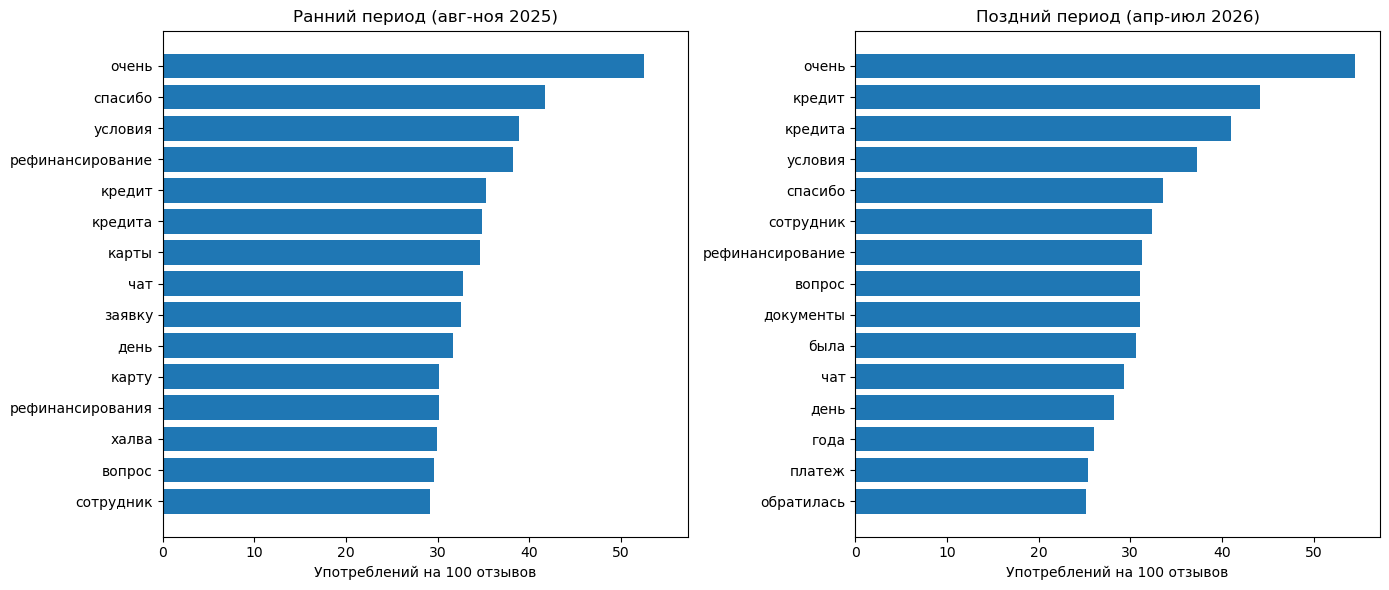

In [23]:
restructing_early = reviews_full_months[
    (reviews_full_months['product'] == 'restructing') &
    (reviews_full_months['dateCreate'].dt.strftime('%Y-%m').isin(['2025-08', '2025-09', '2025-10', '2025-11']))
]

restructing_late = reviews_full_months[
    (reviews_full_months['product'] == 'restructing') &
    (reviews_full_months['dateCreate'].dt.strftime('%Y-%m').isin(['2026-04', '2026-05', '2026-06', '2026-07']))
]

print(f"Ранний период: {len(restructing_early)} отзывов, средний grade: {restructing_early['grade'].mean():.2f}")
print(f"Поздний период: {len(restructing_late)} отзывов, средний grade: {restructing_late['grade'].mean():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)
plot_top_words(top_words_normalized(restructing_early['text'], russian_stopwords), 
               'Ранний период (авг-ноя 2025)', ax=axes[0])
plot_top_words(top_words_normalized(restructing_late['text'], russian_stopwords), 
               'Поздний период (апр-июл 2026)', ax=axes[1])
axes[0].set_xlabel('Употреблений на 100 отзывов')
axes[1].set_xlabel('Употреблений на 100 отзывов')
plt.tight_layout()
plt.show()

In [16]:
print(f"Ранний: доля со 'спасибо': {share_with_word(restructing_early, 'спасибо'):.2%}")
print(f"Поздний: доля со 'спасибо': {share_with_word(restructing_late, 'спасибо'):.2%}")

Ранний: доля со 'спасибо': 37.12%
Поздний: доля со 'спасибо': 29.31%


#### Наблюдения по содержанию

Сдвиг здесь тоже виден, но более мягкий и постепенный, чем резкий контраст у ипотеки. Средний grade подтверждает тренд численно: 4.15 (ранний период) → 3.62 (поздний) - заметное снижение согласуется с общей находкой про индекс до ~83.

По содержанию:
- В раннем периоде заметно выше частота слов благодарности - `спасибо` (2 место, ~40 на 100 отзывов) и общий позитивный тон
- В позднем периоде `спасибо` смещается ниже (5 место, ~34 на 100) - не исчезает полностью, но сдает позиции
- `халва` (продукт Совкомбанка) есть в раннем топе, но выпадает из позднего
- В позднем периоде появляются `документы`, `платеж`, `обратилась` - более процедурная лексика

Численное подтверждение снижения доли благодарственной лексики: доля отзывов со словом "спасибо" падает с 37.12% до 29.31%, согласуется с общим снижением grade.

Выпадение `халва` из позднего топа наводит на гипотезу, что снижение объясняется уменьшением доли Совкомбанка в выборке к концу периода, а не общим трендом по всем банкам. Проверим это разбивкой по банкам.

In [17]:
# проверка гипотезы про совкомбанк отдельно
restructing_early.groupby('bank', observed=True)['grade'].mean()

bank
alfabank      3.692308
sberbank      2.000000
sovcombank    4.656566
tcs           1.659574
vtb           3.000000
Name: grade, dtype: float64

In [18]:
restructing_late.groupby('bank', observed=True)['grade'].mean()

bank
alfabank      2.209302
sberbank      1.348837
sovcombank    4.723022
tcs           2.285714
vtb           1.977273
Name: grade, dtype: float64

#### Вывод

Гипотеза про Совкомбанк не подтвердилась: его средний grade по `restructing` остался практически на том же уровне (4.66 → 4.72, даже немного вырос), а не просел - значит, дело не в уменьшении его доли в выборке.

Реальная картина: три из пяти банков - Альфа-Банк (3.69 → 2.21), Сбербанк (2.00 → 1.35) и ВТБ (3.00 → 1.98) - показывают существенное снижение оценки именно по реструктуризации. Т-Банк, наоборот, вырос (1.66 → 2.29).

Это меняет интерпретацию находки: снижение по `restructing` - не эффект продуктового микса или акций, а похоже на настоящее ухудшение восприятия услуги реструктуризации/рефинансирования у большинства банков в течение года.

## 2. Формальная статистическая проверка основной гипотезы
Различия в распределении grade между банками видны визуально ещё в ноутбуке **[3.EDA](3.EDA.ipynb)**, но "видно на графике" - не то же самое, что "статистически доказано". Проведём формальную проверку в два шага:

1. **Chi-square тест на независимость** - проверяет, действительно ли grade зависит от банка, или наблюдаемые различия можно списать на случайный шум выборки
2. **Cramer's V** - оценивает не факт наличия связи, а её силу

Дополнительно сравним не 5 банков по отдельности, а группы по признаку "есть акция за отзывы"/"нет акции" - это более прямой тест центральной гипотезы исследования.

#### Как работает тест

Chi-square проверяет гипотезу: "распределение оценок одинаковое у всех банков, а различия, которые видны на графиках - просто случайный шум выборки". Механика:
1. Строится таблица наблюдаемых частот (сколько отзывов у каждого банка с каждой оценкой) - это то, что реально есть в данных
2. Считается, какими были бы частоты, если бы grade вообще не зависел от банка (то есть если бы у каждого банка было одинаковое распределение оценок, пропорциональное общему количеству его отзывов) - это "ожидаемые" частоты при справедливости нулевой гипотезы независимости
3. Сравнивается, насколько сильно наблюдаемые частоты отличаются от ожидаемых - это и есть статистика хи-квадрат
4. **p-value** отвечает на вопрос: если бы grade и bank были реально независимы, насколько вероятно было бы случайно получить такое отклонение? Если p-value очень маленький - случайностью это не объяснить, и гипотеза независимости отвергается.  

Используется именно этот тест, потому что и `grade`, и `bank` - категориальные переменные, а хи-квадрат - стандартный инструмент для проверки связи между двумя категориальными переменными.

**Важная оговорка:** при большом объёме выборки (у нас 175К+ строк) p-value почти всегда получается малым, даже если реальная связь слабая - с таким n можно отвергнуть гипотезу независимости почти для любых двух категориальных переменных. Поэтому p-value отвечает только на вопрос "есть ли связь вообще", но не "насколько она сильная". Для того, чтобы ответить на вопрос "Насколько связь сильная?" дополнительно считается **Cramer's V** - та же статистика хи-квадрат, но нормированная на размер выборки и число категорий, дающая число от 0 (нет связи) до 1 (полная связь), не зависящее от объёма данных. Ориентир для интерпретации: ~0.1 - слабая связь, ~0.3 - умеренная, ~0.5+ - сильная.

In [24]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(reviews_by_bank['bank'], reviews_by_bank['grade'])
print(contingency_table)

grade        1.0  2.0  3.0   4.0    5.0
bank                                   
alfabank    3760  439  218  2375  69244
sberbank    3051  373  133    27    435
sovcombank  1626  170  100   642  40101
tcs         2739  278  106   393  11851
vtb         2953  332  117    65   2565


In [28]:
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"Chi2 statistic: {chi2:.2f}")
print(f"p-value: {p_value}")
print(f"Degrees of freedom: {dof}")

Chi2 statistic: 41819.00
p-value: 0.0
Degrees of freedom: 16


In [29]:
n = contingency_table.sum().sum()
min_dim = min(contingency_table.shape) - 1
cramers_v = (chi2 / (n * min_dim)) ** 0.5
print(f"Cramér's V: {cramers_v:.3f}")

Cramér's V: 0.269


#### Результат: 5 банков

p-value = 0.0 - тест уверенно отвергает гипотезу независимости: связь между `grade` и `bank` определённо не случайность.

Cramer's V = 0.269 - умеренная связь. Значение может показаться ниже, чем можно было ожидать по графикам (разброс средних оценок от 1.6 у Сбербанка до 4.8 у Совкомбанка), но это объяснимо: Cramer's V здесь считается по таблице 5×5 и "размазывает" силу связи по всем ячейкам сразу, а не фокусируется только на крайних значениях (1 и 5), где разница максимальна. При этом 0.269 для такой задачи - вполне содержательный эффект, просто не экстремальный.

Следующий логичный шаг - сравнить не 5 банков по отдельности, а сгруппировать их в "есть акция" (Альфа, Совкомбанк, Т-Банк) vs "нет акции" (Сбербанк, ВТБ) и посчитать тот же тест на бинарной группировке. Это более прямой тест центральной гипотезы про акции.

In [30]:
acii_map = {'alfabank': 'есть акция', 'sovcombank': 'есть акция', 'tcs': 'есть акция',
            'sberbank': 'нет акции', 'vtb': 'нет акции'}
reviews_by_bank['acii_group'] = reviews_by_bank['bank'].map(acii_map)

contingency_table_2 = pd.crosstab(reviews_by_bank['acii_group'], reviews_by_bank['grade'])
print(contingency_table_2)

grade        1.0  2.0  3.0   4.0     5.0
acii_group                              
есть акция  8125  887  424  3410  121196
нет акции   6004  705  250    92    3000


In [32]:
chi2_2, p_value_2, dof_2, expected_2 = chi2_contingency(contingency_table_2)

n_2 = contingency_table_2.sum().sum()
min_dim_2 = min(contingency_table_2.shape) - 1
cramers_v_2 = (chi2_2 / (n_2 * min_dim_2)) ** 0.5

print(f"Chi2: {chi2_2:.2f}, p-value: {p_value_2}, Cramer's V: {cramers_v_2:.3f}")

Chi2: 35909.12, p-value: 0.0, Cramer's V: 0.499


#### Результат: группировка по наличию акции

Cramer's V вырос с 0.269 до **0.499** - практически на границе "сильной" связи. Бинарное деление "есть акция/нет акции" объясняет различия в grade заметно лучше, чем разделение на 5 отдельных банков - то есть именно факт наличия акции, а не индивидуальные особенности конкретного банка, является главным фактором, определяющим распределение оценок.

Это статистически обоснованное подтверждение центральной темы исследования: не просто "у банков разные оценки" (что тривиально само по себе), а конкретно - наличие денежного вознаграждения за отзыв объясняет практически половину дисперсии в оценках между группами банков.